In [1]:
# Basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ML tools
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score

# Save model
import joblib
import os

In [2]:
def load_data():
    
    data = {
        "text": [
            "Stock markets rally after positive earnings",
            "Tech companies release new AI software",
            "Football team wins the championship match",
            "Doctors warn about rising health risks",
            "Investment banking sees strong growth",
            "New smartphone launched with advanced features",
            "Basketball player scores record points",
            "Health officials promote regular exercise",
            "Economic outlook improves for global markets",
            "Breakthrough in machine learning research",
            "Tennis finals attract millions of viewers",
            "Nutrition experts recommend balanced diets",
            
            "Business leaders discuss economic reforms",
            "Latest software update improves security",
            "Cricket team prepares for world cup",
            "New vaccine improves immunity",
            "Market analysts predict recession",
            "AI startup raises millions in funding",
            "Olympic athletes train hard",
            "Mental health awareness increases"
        ],
        
        "category": [
            "business","technology","sports","health",
            "business","technology","sports","health",
            "business","technology","sports","health",
            "business","technology","sports","health",
            "business","technology","sports","health"
        ]
    }
    
    return pd.DataFrame(data)


# Load dataset
df = load_data()

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (20, 2)


,text,category
0,Stock markets rally after positive earnings,business
1,Tech companies release new AI software,technology
2,Football team wins the championship match,sports
3,Doctors warn about rising health risks,health
4,Investment banking sees strong growth,business


In [3]:
X_train, X_val, y_train, y_val = train_test_split(
    df["text"],
    df["category"],
    test_size=0.25,
    random_state=42,
    stratify=df["category"]
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))

Training samples: 15
Validation samples: 5


In [4]:
pipeline = Pipeline([
    
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        max_features=5000
    )),
    
    ("model", LogisticRegression(
        max_iter=1000,
        multi_class="auto"
    ))
])

In [5]:
pipeline.fit(X_train, y_train)

print("Model training completed")

Model training completed


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [7]:
preds = pipeline.predict(X_val)

f1 = f1_score(y_val, preds, average="macro")

print("Macro F1 Score:", f1)

Macro F1 Score: 0.5833333333333333


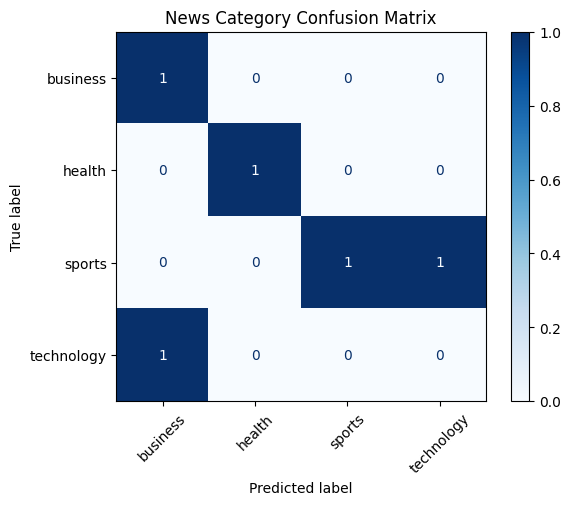

In [8]:
labels = sorted(df["category"].unique())

cm = confusion_matrix(y_val, preds, labels=labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("News Category Confusion Matrix")
plt.show()

In [9]:
# Create folders
os.makedirs("models", exist_ok=True)

# Save model
joblib.dump(pipeline, "models/news_classifier.joblib")

# Save metrics
metrics = {"macro_f1": float(f1)}

import json

with open("models/metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Model and metrics saved")

Model and metrics saved


In [15]:
def predict_news(text):
    pred = pipeline.predict([text])[0]
    return pred


# Try examples
print(predict_news("Stock prices fall after budget announcement"))
print(predict_news("New AI chip improves performance"))
print(predict_news("Player scores winning goal"))
print(predict_news("Doctors advise healthy lifestyle"))
print(predict_news("palyers win the match of footbal"))

business
technology
sports
health
sports
